First attempt at a model of a photodiode. First start with idealized behaviour.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# ── Physical constants ────────────────────────────────────────────────────────
q   = 1.602e-19   # Elementary charge [C]
eps0= 8.854e-12   # Permittivity of free space [F/m]
hc  = 1.986e-25   # h·c  [J·m]
kB  = 1.381e-23   # Boltzmann constant [J/K]

# Material parameters, InP
MATERIALS = {
    "InP": {
        "description"    : "InP",
        "bandgap_eV"     : 1.35,          # E_g [eV]
        "epsilon_r"      : 11.7,          # Relative permittivity
        "mu_n"           : 0.1350,        # Electron mobility [m²/V·s]
        "mu_p"           : 0.0480,        # Hole mobility [m²/V·s]
        "tau_n"          : 1e-6,          # Electron lifetime [s]  (lightly doped)
        "tau_p"          : 1e-6,          # Hole lifetime [s]
        "n_i"            : 9.65e9 * 1e6,  # Intrinsic carrier density [m⁻³]
        "alpha_coeff"    : (1e7, 1.e-6), # (α₀ [m⁻¹], λ_gap [m]) for Urbach model
        "D_n"            : 0.0025,        # Electron diffusivity [m²/s]  (D=μkT/q)
        "D_p"            : 0.00125,
    },
    "Si": {
        "description"    : "Silicon — workhorse detector, NIR",
        "bandgap_eV"     : 1.12,          # E_g [eV]
        "epsilon_r"      : 11.7,          # Relative permittivity
        "mu_n"           : 0.1350,        # Electron mobility [m²/V·s]
        "mu_p"           : 0.0480,        # Hole mobility [m²/V·s]
        "tau_n"          : 1e-6,          # Electron lifetime [s]  (lightly doped)
        "tau_p"          : 1e-6,          # Hole lifetime [s]
        "n_i"            : 9.65e9 * 1e6,  # Intrinsic carrier density [m⁻³]
        "alpha_coeff"    : (1e7, 1.1e-6), # (α₀ [m⁻¹], λ_gap [m]) for Urbach model
        "D_n"            : 0.0025,        # Electron diffusivity [m²/s]  (D=μkT/q)
        "D_p"            : 0.00125,
    },
}

In [3]:
## Input
import numpy as np
length = 5000
wavelengths = np.linspace(1e-7, 2e-6, length)



In [ ]:
# Functions
# photon enegery based on wavelength
def photon_energy(wavelength: float) -> float:
    """Photon energy E_ph = hc/λ [J]."""
    return hc / wavelength

## absorption_coefficient
def absorption_coefficient(
        wavelength: float, 
        material: dict) -> float:
    """
    Simple Urbach-edge model for the absorption coefficient α [m⁻¹].
 
    Below the bandgap: α ≈ 0 (transparent).
    Above the bandgap: α grows steeply.  We use a piecewise power-law
    calibrated to α₀ at the gap wavelength λ_gap:
 
        α(λ) = α₀ · exp( (λ_gap/λ - 1) · 20 )    for λ < λ_gap
             = 0                                    for λ ≥ λ_gap
 
    This is intentionally simplified; replace with tabulated data for accuracy.
    """
    alpha0, _ = material["alpha_coeff"]
    E_ph = photon_energy(wavelength)      # now array-compatible
    E_g  = material["bandgap_eV"] * q     # 

    alpha = np.zeros_like(E_ph)
    mask = E_ph > E_g
    alpha[mask] = alpha0 * np.exp(10 * (E_ph[mask] / E_g - 1.0))
    alpha = np.minimum(alpha, alpha0 * 1e3)
    
    return alpha

## Generation rate, eh pairs generated from incident photons depends on: Wavelength, incident flux, quantum efficiency.
def generation_rate(
    wavelength: float,
    flux: float,
    material: dict,
    thickness: float,
    eta_ext: float = 1.0,
) -> float:
    """
    Volumetric generation rate G [m⁻³ s⁻¹].
 
    G = η_ext · η_abs · Φ / d
 
    where:
      η_ext  = external quantum efficiency (coupling, reflection losses)
      η_abs  = 1 - exp(-α·d)  (fraction of photons absorbed in thickness d)
      Φ      = incident photon flux [photons/m²/s]
      d      = absorption layer thickness [m]
 
    Each absorbed photon creates one electron-hole pair (one carrier).
    """
    alpha   = absorption_coefficient(wavelength, material)
    eta_abs = 1.0 - np.exp(-alpha * thickness)
    G       = eta_ext * eta_abs * flux / thickness
    return G, alpha, eta_abs

## Recombination rate, share of eh pairs that recombine. depends on carrier lifetime.



Test run


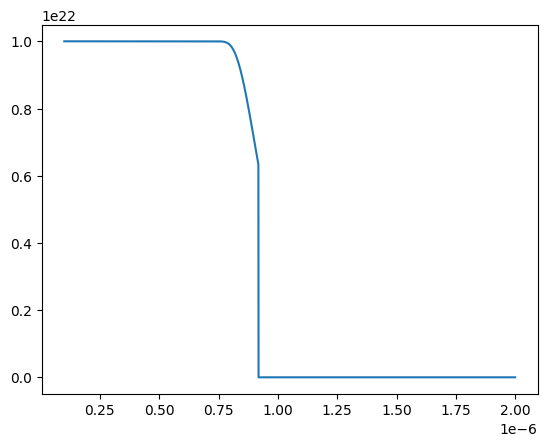

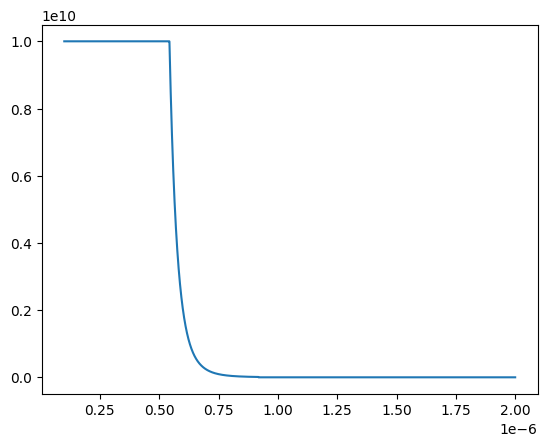

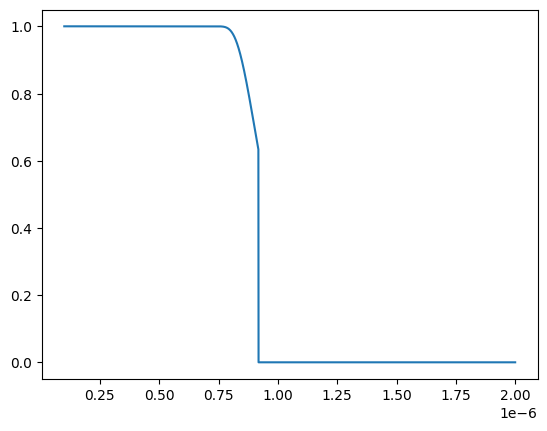

In [ ]:
## Testing and running the functions, try to understand

if __name__ == "__main__":
    material_name: str = "InP"
    flux = 1e15
    d = 100e-9
    print('Test run')
    photon_energies = photon_energy(wavelengths)
    alphas = absorption_coefficient(wavelengths, MATERIALS[material_name])
    #plt.plot(photon_energies, alphas)
    G, alpha, eta_abs = generation_rate(wavelengths, flux, MATERIALS[material_name], d)
    plt.figure()
    plt.plot(wavelengths, G, label="G")
    plt.figure()
    plt.plot(wavelengths, alpha, label="alpha")
    plt.figure()
    plt.plot(wavelengths, eta_abs, label="eta_abs")
   

In [ ]:
## Code from scratch: First, power that actually gets absorped in the active area of p-i-n diode
import numpy as np 
import matplotlib.pyplot as plt
# ── Physical constants ────────────────────────────────────────────────────────
q   = 1.602e-19   # Elementary charge [C]
eps0= 8.854e-12   # Permittivity of free space [F/m]
hc  = 1.986e-25   # h·c  [J·m]
kB  = 1.381e-23   # Boltzmann constant [J/K]

wavelength = 1550e-9
reflection = 0.2
d = 100e-9
alpha = 1.5e5
alpha_x1 = 1e5
alpha_x2 = 1.5e3
x1 = 10e-9
x2 = 500e-9

# Initial power
P_0 = 1e-3

P_x1 = 1 - np.exp(-alpha_x1 * x1)
P = (1-reflection) * (1-P_x1) * P_0 * np.exp(alpha * d)
print(P_0)
print(P_x1)
print(P)

##
def absorbed_power(P):
    P_a = P*0.8
    return P_a

## Amount of photons for a given power and wavelength.
def photon_flux(P, wavelength):
    flux = (P*wavelength) / (hc)
    return flux

# number of eh pairs per photon, quantum effiency
def absorption(flux, eta):
    ehpairs = flux * eta
    return ehpairs

flux = photon_flux(P_0, wavelength)
print(flux)

0.001
0.000999500166624978
0.000811278767150794
7804632426988923.0


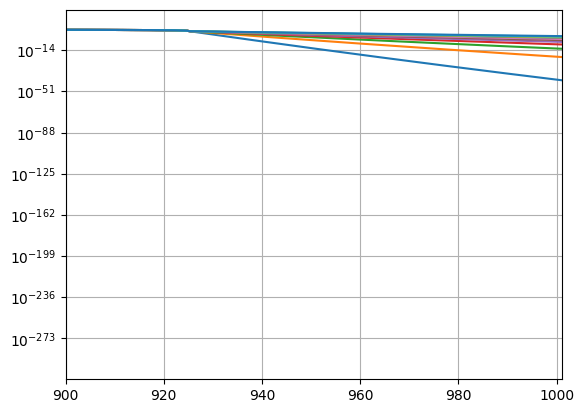

In [28]:
# Absorption based on wavelength
import numpy as np
import matplotlib.pyplot as plt

length = 5000
wavelengths = np.linspace(1, 2000, length)
def alpha_inp(lambda_nm,
              Eg=1.34,        # bandgap in eV (InP at 300K)
              A=1e5,          # scaling factor (cm^-1 eV^-1/2)
              EU=0.007,       # Urbach energy in eV (~5–10 meV typical)
              alpha0=1e3):    # prefactor for Urbach tail (cm^-1)
    """
    Absorption coefficient for InP using a simplified Adachi-like model.

    Parameters:
        lambda_nm : float or np.array
            Wavelength in nm
        Eg : float
            Bandgap energy (eV)
        A : float
            Above-bandgap scaling constant
        EU : float
            Urbach energy (eV)
        alpha0 : float
            Tail prefactor (cm^-1)

    Returns:
        alpha : float or np.array
            Absorption coefficient (cm^-1)
    """
    # constants
    h = 4.135667696e-15  # eV*s
    c = 2.99792458e8     # m/s

    # convert wavelength to energy (eV)
    lambda_m = np.array(lambda_nm) * 1e-9
    E = (h * c) / lambda_m

    alpha = np.zeros_like(E)

    # above bandgap
    mask_above = E > Eg
    alpha[mask_above] = A * np.sqrt(E[mask_above] - Eg)

    # below bandgap (Urbach tail)
    mask_below = ~mask_above
    alpha[mask_below] = alpha0 * np.exp((E[mask_below] - Eg) / EU)

    return alpha


urbachs = np.linspace(0.001, 0.01, 11)
plt.figure()
for urbach in urbachs:
    alpha_inp_array = alpha_inp(wavelengths, EU = urbach)
    plt.plot(wavelengths, alpha_inp_array)
    
plt.yscale('log')
plt.xlim(900, 1001)
plt.grid()
